In [38]:
import random

In [39]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [40]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [41]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,3.755614,-0.145426,0.580294,-1.038424,-3.271241,0
1,1.446618,3.148431,-0.592959,-2.829179,-1.939559,0
2,1.355967,0.682576,-0.826654,-1.800739,-2.254883,0
3,-0.524219,-1.254293,2.140729,-1.263323,2.710848,1
4,-1.996997,-1.597650,2.002073,-0.882833,1.461243,1


In [42]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [43]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [44]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [45]:
df1 = combined_sampling(df,0.5,0.5)

/var/folders/3l/qx11j48x2t99ylq302z95n6m0000gn/T/ipykernel_57437/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [46]:
df2 = combined_sampling(df,0.5,0.5)

/var/folders/3l/qx11j48x2t99ylq302z95n6m0000gn/T/ipykernel_57437/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [47]:
df3 = combined_sampling(df,0.5,0.5)

/var/folders/3l/qx11j48x2t99ylq302z95n6m0000gn/T/ipykernel_57437/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [48]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col1', 'target'], dtype='object')
Index(['col2', 'col4', 'target'], dtype='object')
Index(['col3', 'col5', 'target'], dtype='object')


In [49]:
df3

,col3,col5,target
72,-1.915124,1.129827,0
65,-0.982334,1.063510,0
75,-0.246724,-2.087530,0
62,-2.172380,-1.697991,0
89,-0.769418,-0.944888,0
41,0.049494,-1.181003,0
1,-0.592959,-1.939559,0
19,-0.535578,-2.625018,0
91,-2.346811,-1.236432,0
11,1.515118,1.630874,1


In [50]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [51]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [52]:
from sklearn.tree import plot_tree

[Text(0.5892857142857143, 0.9285714285714286, 'x[0] <= -0.224\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.39285714285714285, 0.7857142857142857, 'x[0] <= -1.971\ngini = 0.444\nsamples = 33\nvalue = [11, 22]'),
 Text(0.4910714285714286, 0.8571428571428572, 'True  '),
 Text(0.32142857142857145, 0.6428571428571429, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.4642857142857143, 0.6428571428571429, 'x[0] <= -0.71\ngini = 0.26\nsamples = 26\nvalue = [4, 22]'),
 Text(0.2857142857142857, 0.5, 'x[0] <= -1.358\ngini = 0.172\nsamples = 21\nvalue = [2, 19]'),
 Text(0.14285714285714285, 0.35714285714285715, 'x[0] <= -1.396\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.07142857142857142, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.21428571428571427, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.42857142857142855, 0.35714285714285715, 'x[1] <= 1.59\ngini = 0.105\nsamples = 18\nvalue = [1, 17]'),
 Text(0.35714285714285

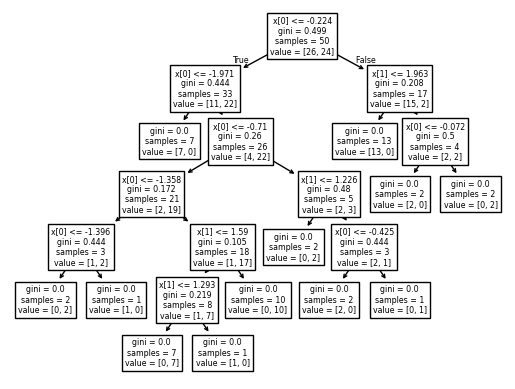

In [53]:
plot_tree(clf1)

[Text(0.6, 0.9285714285714286, 'x[0] <= -0.671\ngini = 0.461\nsamples = 50\nvalue = [32, 18]'),
 Text(0.4, 0.7857142857142857, 'x[0] <= -1.989\ngini = 0.491\nsamples = 30\nvalue = [13, 17]'),
 Text(0.5, 0.8571428571428572, 'True  '),
 Text(0.3, 0.6428571428571429, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.5, 0.6428571428571429, 'x[1] <= -0.534\ngini = 0.351\nsamples = 22\nvalue = [5, 17]'),
 Text(0.4, 0.5, 'x[1] <= -0.981\ngini = 0.473\nsamples = 13\nvalue = [5, 8]'),
 Text(0.2, 0.35714285714285715, 'x[0] <= -1.011\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.1, 0.21428571428571427, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.3, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.35714285714285715, 'x[0] <= -1.602\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.5, 0.21428571428571427, 'x[1] <= -0.73\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.4, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 

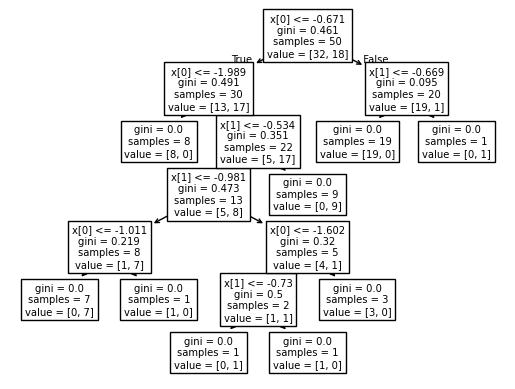

In [54]:
plot_tree(clf2)

[Text(0.5909090909090909, 0.9, 'x[0] <= 0.278\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.36363636363636365, 0.7, 'x[1] <= -0.26\ngini = 0.18\nsamples = 30\nvalue = [27, 3]'),
 Text(0.4772727272727273, 0.8, 'True  '),
 Text(0.18181818181818182, 0.5, 'x[0] <= -0.965\ngini = 0.074\nsamples = 26\nvalue = [25, 1]'),
 Text(0.09090909090909091, 0.3, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.2727272727272727, 0.3, 'x[0] <= -0.85\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.18181818181818182, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.36363636363636365, 0.1, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.5454545454545454, 0.5, 'x[0] <= -0.624\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.45454545454545453, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6363636363636364, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8181818181818182, 0.7, 'x[1] <= -2.847\ngini = 0.095\nsamples = 20\nvalue = [1, 19]'),
 Text(

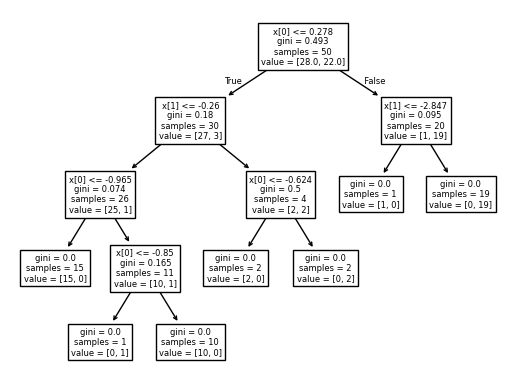

In [55]:
plot_tree(clf3)

In [56]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/Users/sefayet/.pyenv/versions/3.11.6/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [57]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/Users/sefayet/.pyenv/versions/3.11.6/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [58]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/Users/sefayet/.pyenv/versions/3.11.6/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [59]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
96,0.730536,-1.189149,1.000815,-0.522139,1.354079,1
28,1.450029,-0.983293,1.305436,-0.721255,1.843916,1
37,1.704621,-0.792989,0.147876,0.177224,-0.940064,1
90,-0.126403,-0.965598,1.740786,-1.145056,1.430917,1
46,-0.595503,-0.960998,-0.823507,-1.126593,0.569532,0
3,-0.524219,-1.254293,2.140729,-1.263323,2.710848,1
27,1.833044,-1.575233,-1.294615,-0.777726,-3.086088,0
16,0.887635,1.542812,-2.046703,-2.206415,-0.575415,0
23,0.587600,-1.204390,1.750161,-0.848819,2.232130,1
2,1.355967,0.682576,-0.826654,-1.800739,-2.254883,0
